In [2]:
import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

BASE = Path(r"C:\clara-system\ai-services\ml_service")
model = joblib.load(BASE / "model.pkl")
with open(BASE / "model_meta.json") as f:
    meta = json.load(f)

print("Model loaded")
print("Targets:", meta["target_names"])

Model loaded
Targets: ['lvef_lte_45_flag', 'shd_moderate_or_greater_flag', 'lvwt_gte_13_flag', 'pasp_gte_45_flag', 'rv_systolic_dysfunction_moderate_or_greater_flag', 'mitral_regurgitation_moderate_or_greater_flag', 'aortic_stenosis_moderate_or_greater_flag', 'pericardial_effusion_moderate_large_flag']


In [3]:
with open(BASE / "column_config.json") as f:
    config = json.load(f)

df = pd.read_csv(BASE / config["csv_file"], low_memory=False)
test_df = df[df[config["split_column"]] != config["split_train_value"]].copy()

enc = config["categorical_encodings"]["sex"]
test_df["sex"] = test_df["sex"].map(enc).fillna(test_df["sex"])

feature_names = list(config["feature_columns"].keys())
target_names  = list(config["target_columns"].keys())

X_test = pd.DataFrame()
for std, csv in config["feature_columns"].items():
    X_test[std] = pd.to_numeric(test_df[csv], errors="coerce")

Y_test = pd.DataFrame()
for std, csv in config["target_columns"].items():
    Y_test[std] = pd.to_numeric(test_df[csv], errors="coerce").fillna(0).astype(int)

print(f"Test rows: {len(X_test):,}")

Test rows: 27,525


In [4]:
y_pred     = model.predict(X_test)
proba_list = model.predict_proba(X_test)
print("Predictions done")

Predictions done


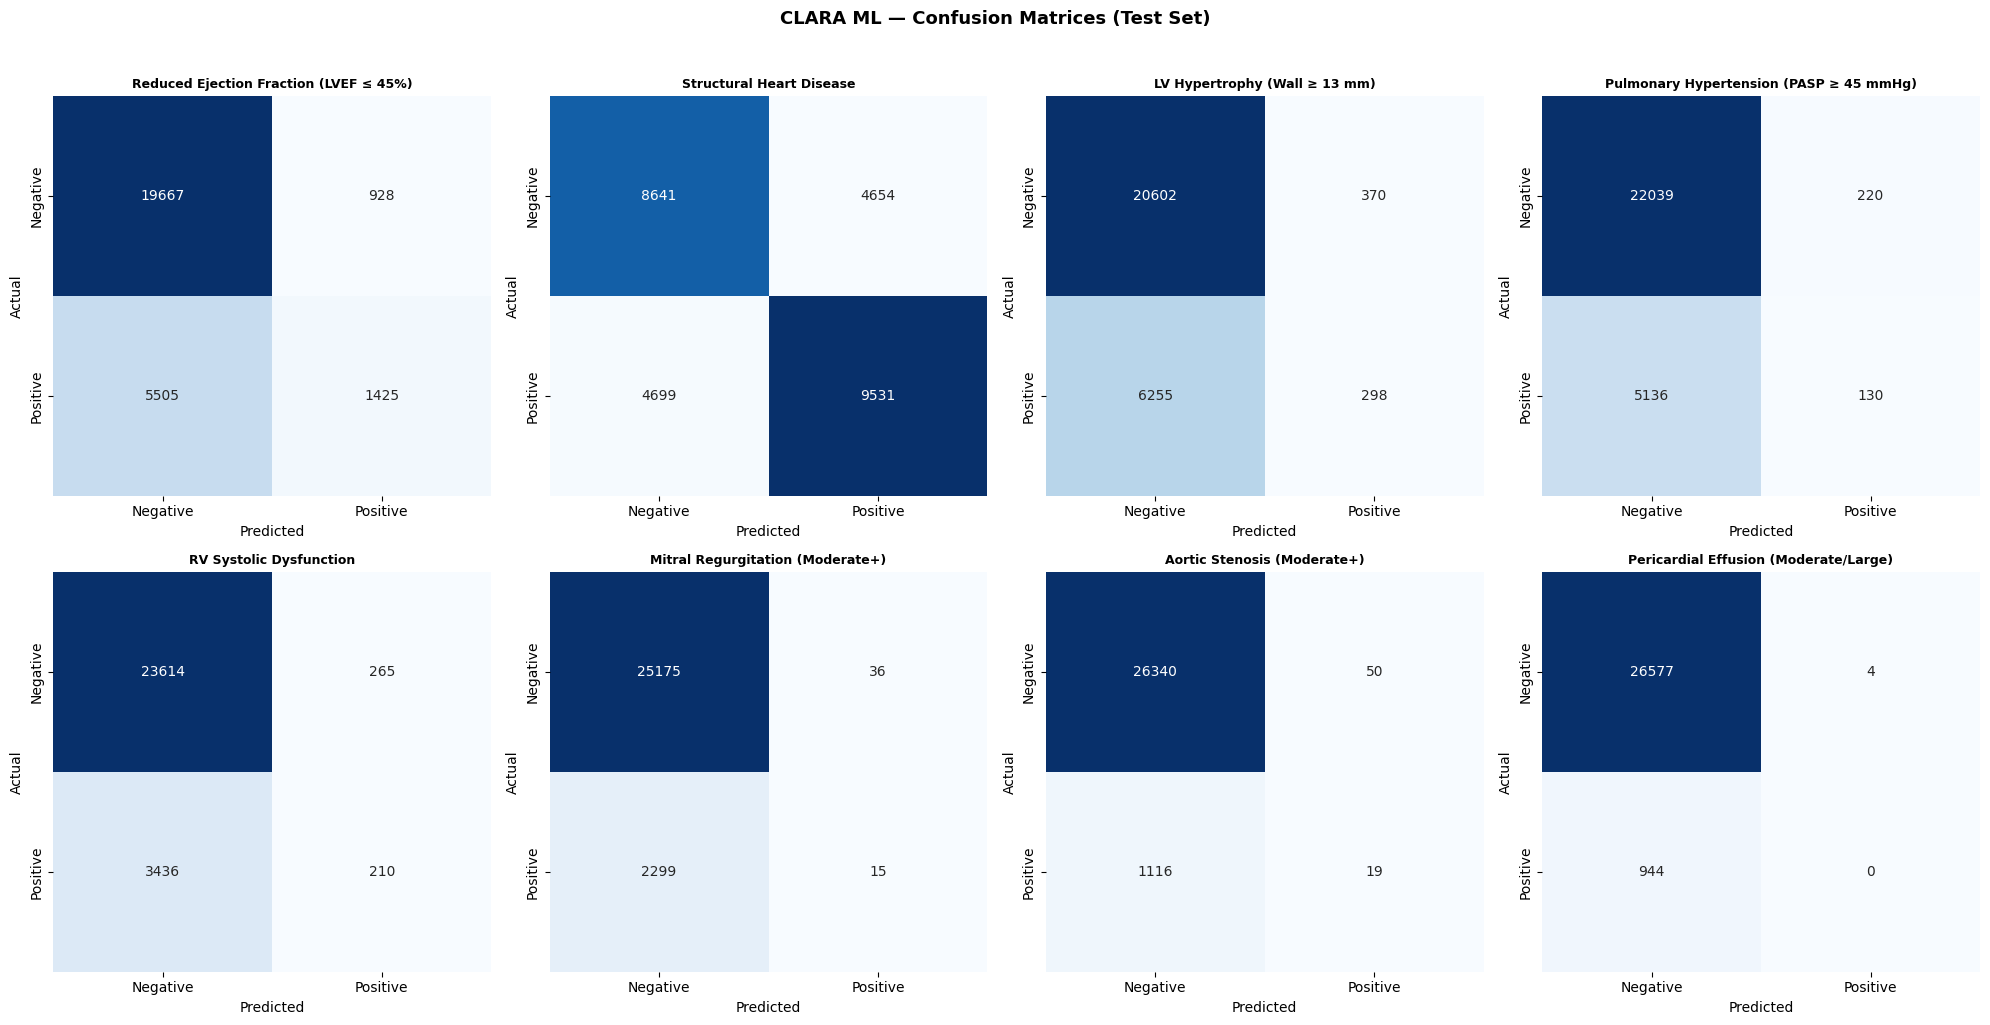

Saved: confusion_matrices.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, name in enumerate(target_names):
    cm    = confusion_matrix(Y_test.iloc[:, i], y_pred[:, i])
    label = meta["target_labels"].get(name, name)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=axes[i], cbar=False,
    )
    axes[i].set_title(label, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("CLARA ML — Confusion Matrices (Test Set)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(BASE / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

In [6]:
rows = []
for i, name in enumerate(target_names):
    true  = Y_test.iloc[:, i].values
    probs = proba_list[i][:, 1]
    auroc = roc_auc_score(true, probs)
    rows.append({
        "Condition":  meta["target_labels"].get(name, name),
        "AUROC":      round(auroc, 4),
        "Prevalence": f"{true.mean()*100:.1f}%",
        "Test N":     len(true),
    })

summary = pd.DataFrame(rows).sort_values("AUROC", ascending=False)
summary

,Condition,AUROC,Prevalence,Test N
6,Aortic Stenosis (Moderate+),0.8493,4.1%,27525
0,Reduced Ejection Fraction (LVEF ≤ 45%),0.7396,25.2%,27525
4,RV Systolic Dysfunction,0.7277,13.2%,27525
1,Structural Heart Disease,0.7250,51.7%,27525
5,Mitral Regurgitation (Moderate+),0.7062,8.4%,27525
2,LV Hypertrophy (Wall ≥ 13 mm),0.6627,23.8%,27525
3,Pulmonary Hypertension (PASP ≥ 45 mmHg),0.6364,19.1%,27525
7,Pericardial Effusion (Moderate/Large),0.5990,3.4%,27525
